<a href="https://colab.research.google.com/github/Lu8na/IT362/blob/main/Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Cleaned dataset


In [ ]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

## 1.1 Loading data

In [2]:
df = pd.read_csv('/content/primary_google_beauty_reviews_cleaned.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1208 entries, 0 to 1207
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   review_id        1208 non-null   int64 
 1   business_id      1208 non-null   object
 2   stars            1208 non-null   int64 
 3   sentiment_label  1208 non-null   object
 4   clean_text       1208 non-null   object
 5   processed_text   1206 non-null   object
 6   date             1207 non-null   object
dtypes: int64(2), object(5)
memory usage: 66.2+ KB


The cleaned dataset from Phase 2 was loaded into the notebook. This dataset contains preprocessed textual reviews along with their corresponding sentiment labels. Initial inspection was performed to understand the structure of the dataset and verify that all required columns are available for the modelling phase.

## 1.2 Selecting features & target

In [3]:
text_col = "processed_text"
target_col = "sentiment_label"

Only the relevant columns were selected for modelling. The 'processed_text' column was chosen as the input feature since it contains cleaned and preprocessed textual data. The 'sentiment_label' column was selected as the target variable, representing the sentiment class for each review. All missing values were removed to ensure data quality and prevent errors during the modelling process.

## 1.3 Spreating X and Y

In [4]:
df = df[[text_col, target_col]].dropna()

X_text = df[text_col].astype(str)
y = df[target_col]

The dataset was divided into two main components: the input feature (X_text), which contains the processed textual reviews, and the target variable (y), which contains the corresponding sentiment labels. This separation is necessary for training machine learning models.

In [5]:
print(df.shape)
print(X_text.head())
print(y.head())

(1206, 2)
0    finally went liberty london amazing store ente...
1    really nice shopping day liberty christmas dec...
2    liberty destination dream anyone sews stitch e...
3    beautiful store amazing range age amazing hist...
4    cool building inside really came cruella movie...
Name: processed_text, dtype: object
0    Positive
1    Positive
2    Positive
3    Positive
4    Positive
Name: sentiment_label, dtype: object


## 1.4 Bag of words (BOW)

In [6]:
bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(X_text)

In [7]:
print("Bag of Words shape:", X_bow.shape)
print("Number of BOW features:", len(bow_vectorizer.get_feature_names_out()))

Bag of Words shape: (1206, 6157)
Number of BOW features: 6157


The Bag of Words technique was applied to convert textual data into numerical form. This method represents each review as a vector based on the frequency of words appearing in the dataset. It allows machine learning models to process text by transforming it into a structured numerical format.


## 1.5 TF-IDF

In [8]:
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(X_text)

In [9]:
print("TF-IDF shape:", X_tfidf.shape)
print("Number of TF-IDF features:", len(tfidf_vectorizer.get_feature_names_out()))

TF-IDF shape: (1206, 6157)
Number of TF-IDF features: 6157


TF-IDF (Term Frequency–Inverse Document Frequency) was applied as an alternative text representation technique. Unlike Bag of Words, TF-IDF assigns higher importance to words that are more informative and less frequent across the dataset. This helps improve model performance by reducing the impact of common and less meaningful words.

## 1.6 Train-Test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (964, 6157)
X_test shape: (242, 6157)
y_train shape: (964,)
y_test shape: (242,)


The dataset was split into training and testing sets using an 80/20 ratio. A fixed random state was used to ensure reproducibility of results. Stratified sampling was applied to preserve the distribution of sentiment classes across both sets, ensuring a fair and balanced evaluation of the models.

## Baseline Model – Logistic Regression

A baseline classification model was implemented using Logistic Regression to establish a reference performance for sentiment classification.

The processed review text was converted into numerical features using TF-IDF vectorization. The dataset was split into training and testing sets, and the model was trained on the training data and evaluated on unseen test data.

Evaluation metrics include accuracy, precision, recall, and F1-score, along with a confusion matrix to analyze class-wise performance.

In [13]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [15]:
y_pred_baseline = baseline_model.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(y_test, y_pred_baseline)
precision = precision_score(y_test, y_pred_baseline, average='weighted')
recall = recall_score(y_test, y_pred_baseline, average='weighted')
f1 = f1_score(y_test, y_pred_baseline, average='weighted')

print("Baseline Model Performance:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_baseline))

Baseline Model Performance:
Accuracy: 0.8925619834710744
Precision: 0.8806788749970569
Recall: 0.8925619834710744
F1-score: 0.872777924430817

Classification Report:

              precision    recall  f1-score   support

    Negative       0.96      0.54      0.69        46
     Neutral       0.00      0.00      0.00         5
    Positive       0.88      1.00      0.94       191

    accuracy                           0.89       242
   macro avg       0.62      0.51      0.54       242
weighted avg       0.88      0.89      0.87       242



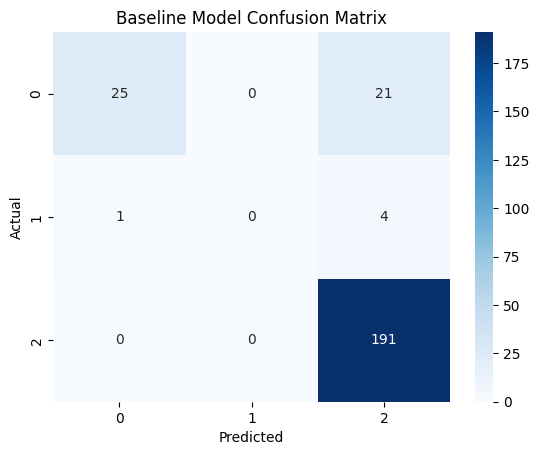

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_baseline)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Baseline Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

---
## Advanced Model 1: Support Vector Machine (SVM)
----

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
svm_model = LinearSVC(random_state=42)

In [ ]:
svm_model.fit(X_train, y_train)
print("SVM model trained successfully.")

SVM model trained successfully.


In [ ]:
y_pred_svm = svm_model.predict(X_test)
print("Predictions completed.")

Predictions completed.


This section presents the performance of the SVM model.  
The model was trained on the training dataset and evaluated using accuracy, precision, recall, and F1-score.  
The confusion matrix is also provided to visualize the classification performance.

In [ ]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.9430051813471503


In [ ]:
report = classification_report(y_test, y_pred_svm, output_dict=True)
report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
Negative,0.890244,0.839080,0.863905,87.000000
Neutral,1.000000,0.083333,0.153846,12.000000
Positive,0.951613,0.983333,0.967213,480.000000
accuracy,0.943005,0.943005,0.943005,0.943005
macro avg,0.947286,0.635249,0.661655,579.000000
weighted avg,0.943394,0.943005,0.934833,579.000000


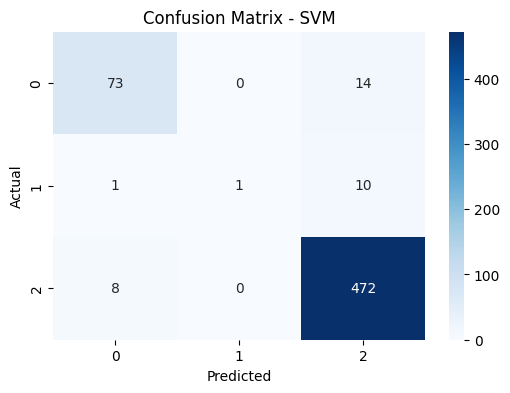

In [ ]:
# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")

plt.show()